## Imports

In [106]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

from prophet import Prophet
from neuralprophet import NeuralProphet
# xgboost
from xgboost import XGBRegressor
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

In [2]:
# Verify cuda is a available
import torch

print(torch.__version__)
print(torch.cuda.is_available())      # Should be True
# print(torch.cuda.get_device_name(0))  # Should show your GPU name

2.5.1+cu121
True


In [101]:
RANDOM_STATE = 42

## Visualization Setup

In [3]:
font_path = '/usr/share/fonts/noto_sans_mono/NotoSansMono_SemiCondensed-SemiBold.ttf'
font_prop = fm.FontProperties(fname=font_path)

sns.set_theme(
    style='darkgrid',
    context='notebook',
    font=font_prop.get_name(),
    rc={
        'font.weight': 'semibold',
        'axes.labelweight': 'semibold',
        'axes.titlesize': 'large',
        'axes.titleweight': 'semibold',
        'axes.labelsize': 'medium',
        }
    )

## Load Data

In [4]:
pjmw_df = pd.read_csv('data/PJMW_hourly.csv')

In [5]:
pjmw_df.shape

(143206, 2)

In [6]:
pjmw_df.isna().sum()

Datetime    0
PJMW_MW     0
dtype: int64

In [7]:
pjmw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  143206 non-null  object 
 1   PJMW_MW   143206 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [8]:
pjmw_df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077.0
1,2002-12-31 02:00:00,4939.0
2,2002-12-31 03:00:00,4885.0
3,2002-12-31 04:00:00,4857.0
4,2002-12-31 05:00:00,4930.0


In [9]:
pjmw_df.rename(columns={'Datetime': 'datetime', 'PJMW_MW': 'mw'}, inplace=True)

In [10]:
pjmw_df['datetime'] = pd.to_datetime(pjmw_df['datetime'])
pjmw_df['year'] = pjmw_df['datetime'].dt.year
pjmw_df['month'] = pjmw_df['datetime'].dt.month
pjmw_df['day'] = pjmw_df['datetime'].dt.day
pjmw_df['hour'] = pjmw_df['datetime'].dt.hour
pjmw_df['day_of_week'] = pjmw_df['datetime'].dt.dayofweek
pjmw_df['day_of_year'] = pjmw_df['datetime'].dt.dayofyear
pjmw_df['week_of_year'] = pjmw_df['datetime'].dt.isocalendar().week
pjmw_df['quarter'] = pjmw_df['datetime'].dt.quarter

## EDA

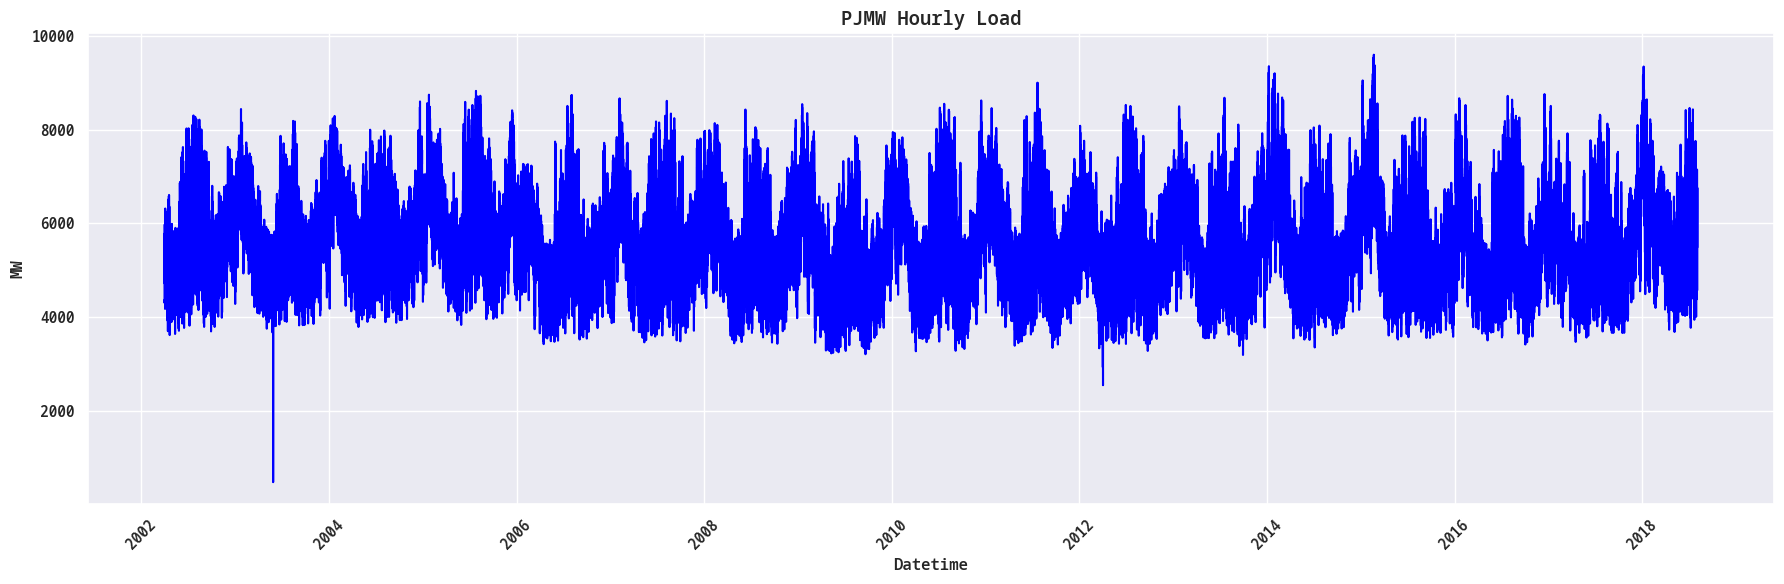

<IPython.core.display.Javascript object>

In [11]:
fig, ax = plt.subplots(figsize=(18, 6))

sns.lineplot(
        data=pjmw_df,
        x='datetime',
        y='mw',
        ax=ax,
        color='blue',
        linewidth=1.5
        )

ax.set_title('PJMW Hourly Load')
ax.set_xlabel('Datetime')
ax.set_ylabel('MW')
ax.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
pjmw_df.head()

,datetime,mw,year,month,day,hour,day_of_week,day_of_year,week_of_year,quarter
0,2002-12-31 01:00:00,5077.0,2002,12,31,1,1,365,1,4
1,2002-12-31 02:00:00,4939.0,2002,12,31,2,1,365,1,4
2,2002-12-31 03:00:00,4885.0,2002,12,31,3,1,365,1,4
3,2002-12-31 04:00:00,4857.0,2002,12,31,4,1,365,1,4
4,2002-12-31 05:00:00,4930.0,2002,12,31,5,1,365,1,4


Let's see how each of the time features correlates with the load (MW).

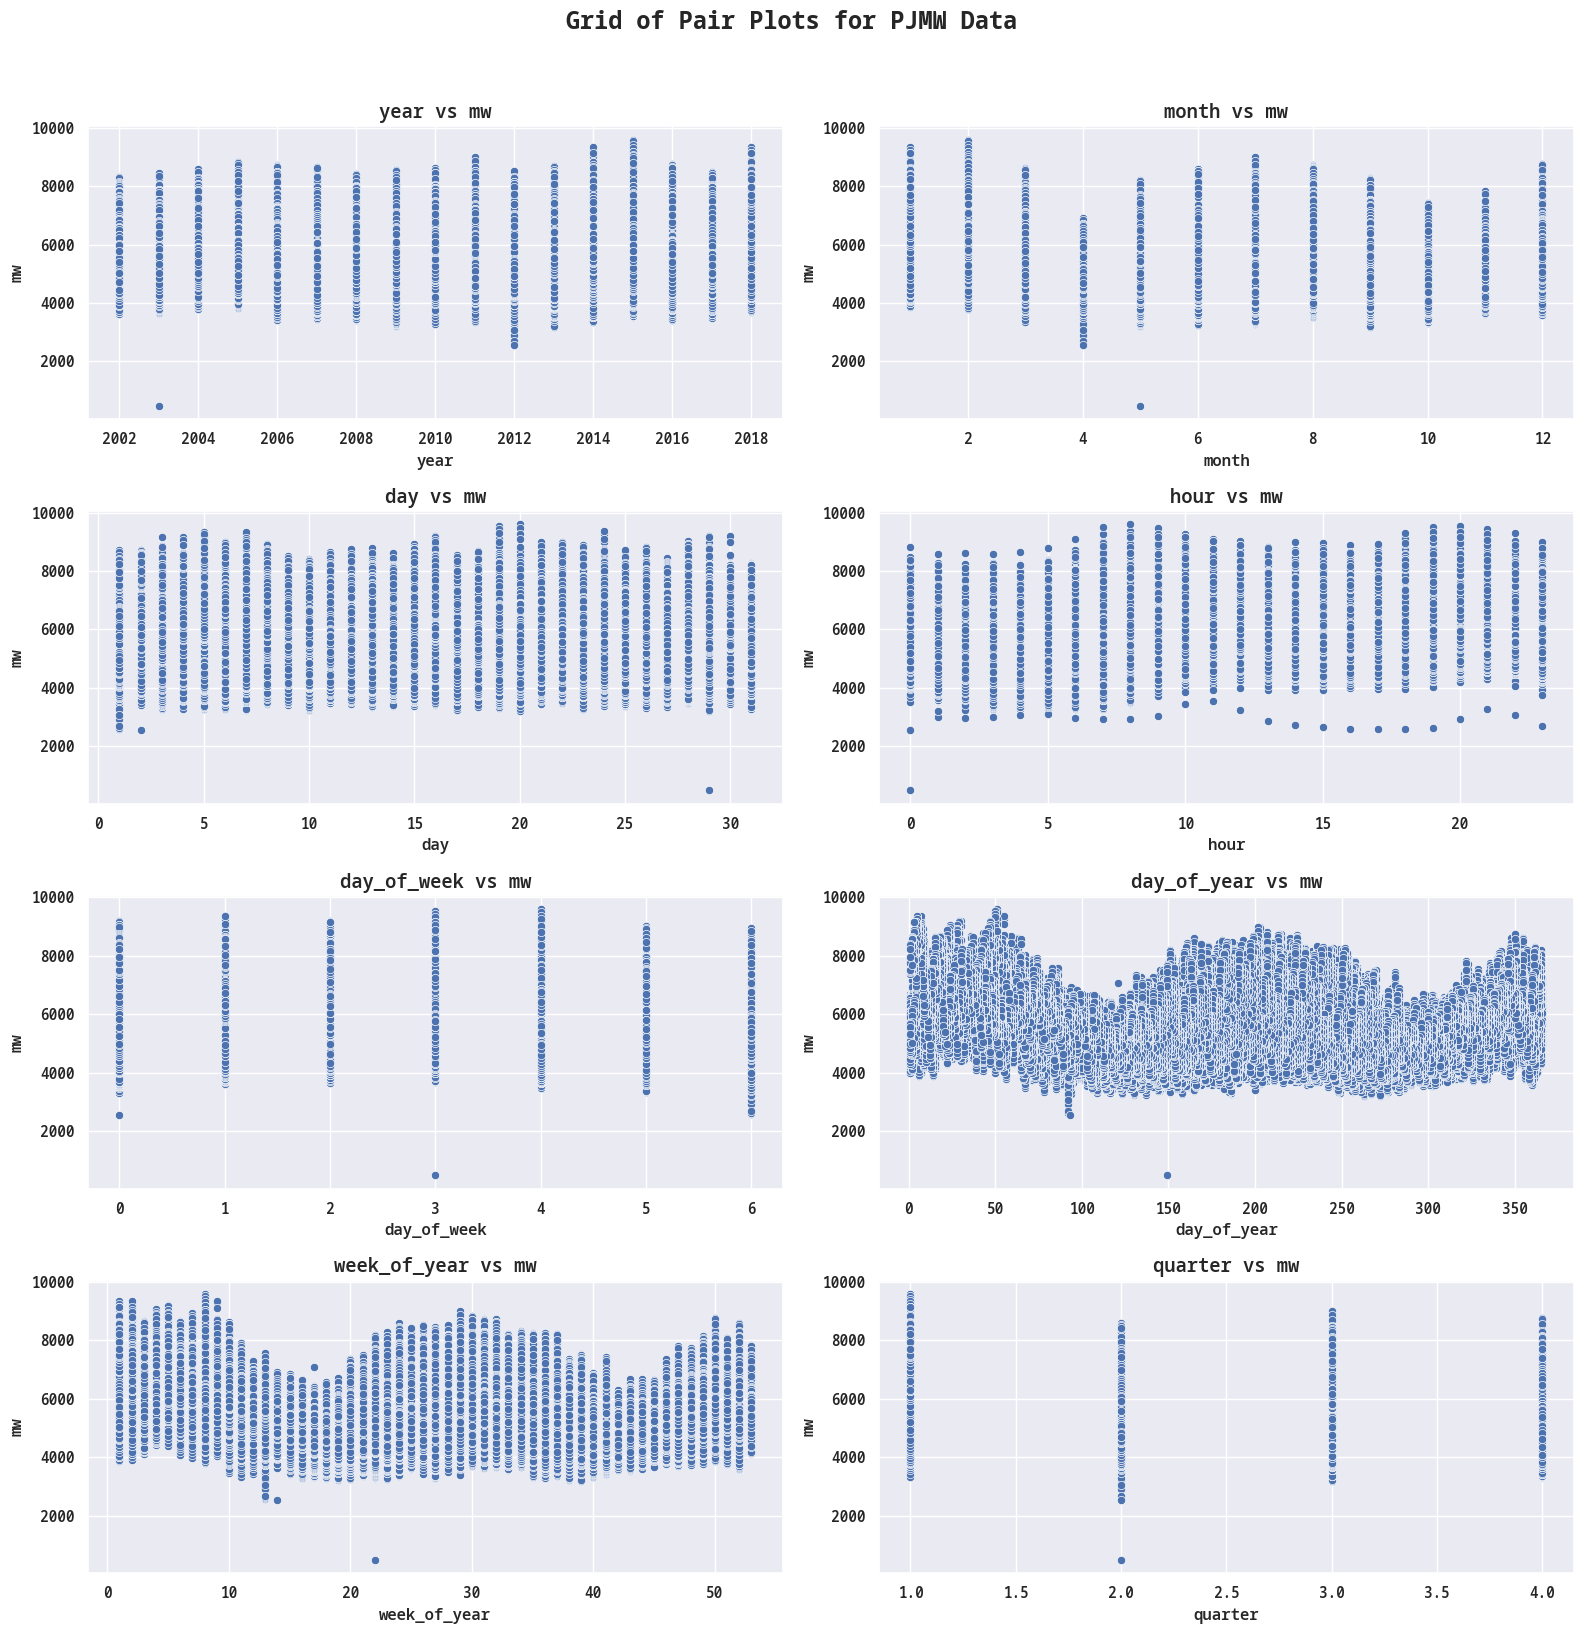

In [13]:
x_vars = [
    'year',
    'month',
    'day',
    'hour',
    'day_of_week',
    'day_of_year',
    'week_of_year',
    'quarter'
]

fig, axes = plt.subplots(4, 2, figsize=(16, 16))  # 4 rows, 2 columns
axes = axes.flatten()

for i, var in enumerate(x_vars):
    sns.scatterplot(data=pjmw_df, x=var, y='mw', ax=axes[i])
    axes[i].set_title(f'{var} vs mw')

plt.suptitle('Grid of Pair Plots for PJMW Data', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
train_val_test_df = pjmw_df.copy()[['datetime', 'mw']]. \
        rename(columns={'datetime': 'ds', 'mw': 'y'}). \
        sort_values(by='ds'). \
        reset_index(drop=True)

train_val_test_df.head()

,ds,y
0,2002-04-01 01:00:00,4374.0
1,2002-04-01 02:00:00,4306.0
2,2002-04-01 03:00:00,4322.0
3,2002-04-01 04:00:00,4359.0
4,2002-04-01 05:00:00,4436.0


In [15]:
train_val_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   ds      143206 non-null  datetime64[ns]
 1   y       143206 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 MB


### Some sanity checks

In [42]:
train_val_test_df['ds'].min(), train_val_test_df['ds'].max()

(Timestamp('2002-04-01 01:00:00'), Timestamp('2018-08-03 00:00:00'))

In [43]:
train_val_test_df.isna().sum()

ds    0
y     0
dtype: int64

In [44]:
train_val_test_df['ds'].value_counts().value_counts()

count
1    143198
2         4
Name: count, dtype: int64

In [45]:
value_counts = train_val_test_df['ds'].value_counts()
value_counts[value_counts > 1].sort_values(ascending=False)

ds
2017-11-05 02:00:00    2
2016-11-06 02:00:00    2
2014-11-02 02:00:00    2
2015-11-01 02:00:00    2
Name: count, dtype: int64

In [46]:
train_val_test_df['ds'].duplicated().sum()

4

In [49]:
train_val_test_df[train_val_test_df['ds'].duplicated(keep=False)].sort_values(by='ds')

,ds,y
110327,2014-11-02 02:00:00,4571.0
110328,2014-11-02 02:00:00,4613.0
119063,2015-11-01 02:00:00,3927.0
119064,2015-11-01 02:00:00,3832.0
127967,2016-11-06 02:00:00,4114.0
127968,2016-11-06 02:00:00,4089.0
136703,2017-11-05 02:00:00,3984.0
136704,2017-11-05 02:00:00,4042.0


Let's drop duplicates and keep the last entry

In [51]:
train_val_test_df = train_val_test_df.drop_duplicates(
        subset='ds',
        keep='last'
        ).reset_index(drop=True)

In [62]:
total_days = (train_val_test_df['ds'].max() - train_val_test_df['ds'].min()).days

train_days = int(0.7 * total_days)
val_days   = int(0.15 * total_days)
test_days  = total_days - train_days - val_days

train_end = train_val_test_df['ds'].min() + pd.Timedelta(days=train_days)
val_end   = train_end + pd.Timedelta(days=val_days)

train_df = train_val_test_df[train_val_test_df['ds'] <= train_end]
val_df   = train_val_test_df[(train_val_test_df['ds'] > train_end) & (train_val_test_df['ds'] <= val_end)]
test_df  = train_val_test_df[train_val_test_df['ds'] > val_end]

In [63]:
# print size, min and max dates of each set
print(f"Train set:      {train_df.shape}, {train_df['ds'].min()} - {train_df['ds'].max()}")
print(f"Validation set: {val_df.shape}, {val_df['ds'].min()} - {val_df['ds'].max()}")
print(f"Test set:       {test_df.shape}, {test_df['ds'].min()} - {test_df['ds'].max()}")

Train set:      (100201, 2), 2002-04-01 01:00:00 - 2013-09-06 01:00:00
Validation set: (21477, 2), 2013-09-06 02:00:00 - 2016-02-18 01:00:00
Test set:       (21524, 2), 2016-02-18 02:00:00 - 2018-08-03 00:00:00


In [64]:
# print the number of NAs in each set

print(f"Train set NAs:      {train_df.isna().sum().sum()}")
print(f"Validation set NAs: {val_df.isna().sum().sum()}")
print(f"Test set NAs:       {test_df.isna().sum().sum()}")

Train set NAs:      0
Validation set NAs: 0
Test set NAs:       0


In [65]:
def objective_prophet(trial):
    params = {
        "changepoint_prior_scale": trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True),
        "seasonality_prior_scale": trial.suggest_float("seasonality_prior_scale", 0.01, 10.0, log=True),
        "holidays_prior_scale":    trial.suggest_float("holidays_prior_scale", 0.01, 10.0, log=True),
        "seasonality_mode":        trial.suggest_categorical("seasonality_mode", ["additive", "multiplicative"]),
        "changepoint_range":       trial.suggest_float("changepoint_range", 0.8, 0.95),
    }

    model = Prophet(**params)
    model.fit(train_df)

    # Forecast on validation
    future_df = model.make_future_dataframe(periods=len(val_df), freq='H')
    forecast_df = model.predict(future_df.tail(len(val_df)))

    # Match forecast to actuals
    y_pred = forecast_df['yhat'].values
    y_true = val_df['y'].values

    return mean_absolute_error(y_true, y_pred)

In [66]:
%%time

study = optuna.create_study(direction="minimize")
study.optimize(objective_prophet, n_trials=50, timeout=600, n_jobs=4)
best_prophet_params = study.best_params.copy()

print("Best parameters:", study.best_params)
print("Best validation MAE:", study.best_value)

[I 2025-06-16 20:13:21,819] A new study created in memory with name: no-name-385a06a6-545c-438f-b8ad-ceb3c773ab87
20:13:48 - cmdstanpy - INFO - Chain [1] start processing
20:13:48 - cmdstanpy - INFO - Chain [1] start processing
20:13:49 - cmdstanpy - INFO - Chain [1] start processing
20:13:49 - cmdstanpy - INFO - Chain [1] start processing
20:16:05 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-06-16 20:16:14,293] Trial 2 finished with value: 611.8912210166867 and parameters: {'changepoint_prior_scale': 0.002181508960304325, 'seasonality_prior_scale': 3.6875712932224474, 'holidays_prior_scale': 0.6512226668917657, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.8657950853312139}. Best is trial 2 with value: 611.8912210166867.
20:16:25 - cmdstanpy - INFO - Chain [1] start processing
20:18:09 - cmdstanpy - INFO - Chain [1] done processing
20:18:14 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-06-16 20:18:18,518] Trial 0 finished with value: 629.9647999611403

Best parameters: {'changepoint_prior_scale': 0.03679688493605646, 'seasonality_prior_scale': 9.968131019913825, 'holidays_prior_scale': 1.0440366232330596, 'seasonality_mode': 'additive', 'changepoint_range': 0.9227731331304833}
Best validation MAE: 608.4965392270612
CPU times: user 2min 39s, sys: 27.1 s, total: 3min 7s
Wall time: 10min 58s


<IPython.core.display.Javascript object>

In [67]:
best_prophet_model = Prophet(**best_prophet_params)
best_prophet_model.fit(train_df)

20:24:26 - cmdstanpy - INFO - Chain [1] start processing
20:25:27 - cmdstanpy - INFO - Chain [1] done processing


<IPython.core.display.Javascript object>

In [70]:
model = best_prophet_model
future_df = model.make_future_dataframe(periods=len(val_df), freq='H')
forecast_df = model.predict(future_df)
forecast_df_val = forecast_df[forecast_df['ds'].isin(val_df['ds'])]

In [71]:
len(val_df)

21477

In [72]:
len(future_df)

121678

In [73]:
len(forecast_df)

121678

In [74]:
len(forecast_df_val)

21474

In [77]:
forecast_df_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21474 entries, 100201 to 121677
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ds                          21474 non-null  datetime64[ns]
 1   trend                       21474 non-null  float64       
 2   yhat_lower                  21474 non-null  float64       
 3   yhat_upper                  21474 non-null  float64       
 4   trend_lower                 21474 non-null  float64       
 5   trend_upper                 21474 non-null  float64       
 6   additive_terms              21474 non-null  float64       
 7   additive_terms_lower        21474 non-null  float64       
 8   additive_terms_upper        21474 non-null  float64       
 9   daily                       21474 non-null  float64       
 10  daily_lower                 21474 non-null  float64       
 11  daily_upper                 21474 non-null  float64  

In [78]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21477 entries, 100201 to 121677
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      21477 non-null  datetime64[ns]
 1   y       21477 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 503.4 KB


In [76]:
forecast_df_val['ds'].duplicated().sum()

0

In [75]:
val_df['ds'].duplicated().sum()

0

In [82]:
set(val_df['ds'].astype(str).values) - set(forecast_df_val['ds'].astype(str).values)

{'2016-02-17 23:00:00', '2016-02-18 00:00:00', '2016-02-18 01:00:00'}

In [83]:
forecast_df_val['ds'].max()

Timestamp('2016-02-17 22:00:00')

In [84]:
forecast_df_val['ds'].min()

Timestamp('2013-09-06 02:00:00')

In [94]:
def evaluate_model(model, val_df):
    # Forecast on validation
    future_df = model.make_future_dataframe(periods=len(val_df), freq='H')
    forecast_df = model.predict(future_df.tail(len(val_df)))

    # Match forecast to actuals
    y_pred_val = forecast_df['yhat'].values
    y_true_val = val_df['y'].values

    val_mae = mean_absolute_error(y_true_val, y_pred_val)

    return val_mae, y_pred_val, y_true_val

def plot_results(y_true_val, y_pred_val):
    plt.figure(figsize=(14, 7))

    # Validation set
    plt.plot(y_true_val, label='Actual (Validation)', color='blue', alpha=0.7)
    plt.plot(y_pred_val, label='Predicted (Validation)', color='orange', linestyle='--', alpha=0.7)
    plt.title('Validation Set Predictions')
    plt.xlabel('Time')
    plt.ylabel('MW')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [96]:
val_mae, y_pred_val, y_true_val = evaluate_model(
    best_prophet_model, val_df
)

val_mean = val_df['y'].mean()
print(f"Validation MAE: {val_mae:.4f}")
print(f"Validation MAE / Mean: {val_mae / val_mean:.4f}")

Validation MAE: 608.4965
Validation MAE / Mean: 0.1075


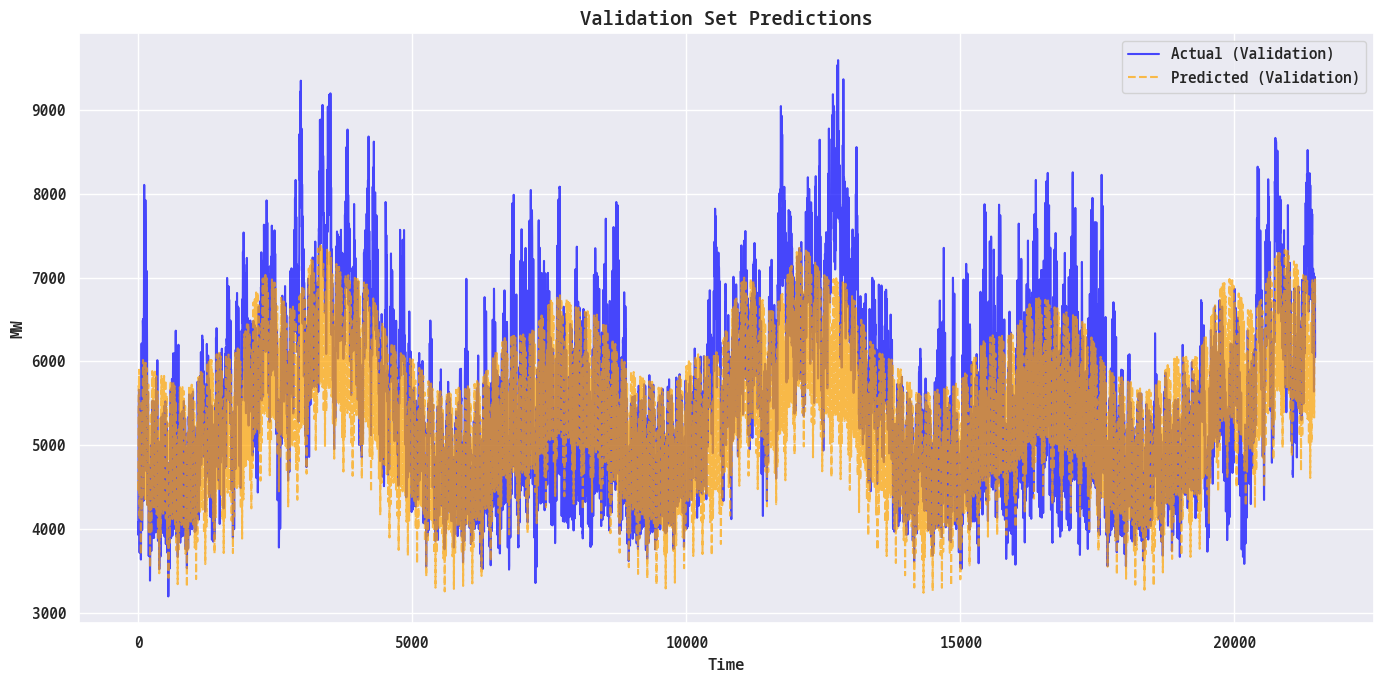

In [97]:
# Plot results
plot_results(y_true_val, y_pred_val)

In [111]:
future_df = model.make_future_dataframe(periods=len(val_df), freq='H')
forecast_df = model.predict(future_df.tail(len(val_df)))
forecast_df

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-09-06 02:00:00,5497.281937,3877.100759,5238.324619,5497.281937,5497.281937,-924.523350,-924.523350,-924.523350,-855.867913,...,154.686422,154.686422,154.686422,-223.341859,-223.341859,-223.341859,0.0,0.0,0.0,4572.758587
1,2013-09-06 03:00:00,5497.280004,3757.081648,5074.516655,5497.280004,5497.280004,-1042.029688,-1042.029688,-1042.029688,-968.014067,...,150.667409,150.667409,150.667409,-224.683031,-224.683031,-224.683031,0.0,0.0,0.0,4455.250315
2,2013-09-06 04:00:00,5497.278070,3788.878532,5155.376795,5497.278070,5497.278070,-1047.516405,-1047.516405,-1047.516405,-967.873542,...,146.379438,146.379438,146.379438,-226.022301,-226.022301,-226.022301,0.0,0.0,0.0,4449.761666
3,2013-09-06 05:00:00,5497.276137,3890.731900,5267.367012,5497.276137,5497.276137,-936.055157,-936.055157,-936.055157,-850.471106,...,141.775593,141.775593,141.775593,-227.359644,-227.359644,-227.359644,0.0,0.0,0.0,4561.220980
4,2013-09-06 06:00:00,5497.274204,4051.076842,5454.166798,5497.274204,5497.274204,-720.720909,-720.720909,-720.720909,-628.832158,...,136.806289,136.806289,136.806289,-228.695039,-228.695039,-228.695039,0.0,0.0,0.0,4776.553295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21472,2016-02-17 18:00:00,5455.770497,3718.215701,9980.377600,2268.798311,8713.339041,1380.443889,1380.443889,1380.443889,509.531636,...,216.297814,216.297814,216.297814,654.614440,654.614440,654.614440,0.0,0.0,0.0,6836.214387
21473,2016-02-17 19:00:00,5455.768564,3636.792982,10153.991856,2268.397464,8713.589977,1480.310954,1480.310954,1480.310954,608.181812,...,217.606778,217.606778,217.606778,654.522364,654.522364,654.522364,0.0,0.0,0.0,6936.079518
21474,2016-02-17 20:00:00,5455.766631,3633.322553,10243.045671,2267.996617,8713.840913,1522.742501,1522.742501,1522.742501,649.657365,...,218.655105,218.655105,218.655105,654.430032,654.430032,654.430032,0.0,0.0,0.0,6978.509132
21475,2016-02-17 21:00:00,5455.764698,3633.163506,10111.476853,2267.595770,8714.091848,1440.710168,1440.710168,1440.710168,566.946396,...,219.426365,219.426365,219.426365,654.337407,654.337407,654.337407,0.0,0.0,0.0,6896.474866


In [112]:
forecast_df.head(1).T

,0
ds,2013-09-06 02:00:00
trend,5497.281937
yhat_lower,3877.100759
yhat_upper,5238.324619
trend_lower,5497.281937
trend_upper,5497.281937
additive_terms,-924.52335
additive_terms_lower,-924.52335
additive_terms_upper,-924.52335
daily,-855.867913


In [113]:
forecast_df.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'daily', 'daily_lower', 'daily_upper', 'weekly', 'weekly_lower',
       'weekly_upper', 'yearly', 'yearly_lower', 'yearly_upper',
       'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [114]:
forecast_df['y'] = val_df['y'].values
forecast_df['residual'] = forecast_df['yhat'] - forecast_df['y']

In [123]:
residual_train_val_test_df = forecast_df.copy().drop(columns=['y'])

residual_train_val_test_df['day'] = residual_train_val_test_df['ds'].dt.day
residual_train_val_test_df['month'] = residual_train_val_test_df['ds'].dt.month
residual_train_val_test_df['year'] = residual_train_val_test_df['ds'].dt.year
residual_train_val_test_df['hour'] = residual_train_val_test_df['ds'].dt.hour
residual_train_val_test_df['day_of_week'] = residual_train_val_test_df['ds'].dt.dayofweek
residual_train_val_test_df['day_of_year'] = residual_train_val_test_df['ds'].dt.dayofyear
residual_train_val_test_df['week_of_year'] = residual_train_val_test_df['ds'].dt.isocalendar().week
residual_train_val_test_df['quarter'] = residual_train_val_test_df['ds'].dt.quarter

residual_train_val_test_df.drop(columns=['ds'], inplace=True)

X = residual_train_val_test_df.drop(columns=['residual', 'yhat'])
y = residual_train_val_test_df['residual']

# Split: train (60%), val (20%), test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.2,
        random_state=RANDOM_STATE, shuffle=False
        )

X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=0.25,
        random_state=RANDOM_STATE,
        shuffle=False
        )

In [124]:
def objective_xgboost(trial):
    params = {
        'tree_method': 'gpu_hist',
        'predictor': 'gpu_predictor',
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': RANDOM_STATE
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred, squared=False)  # RMSE

    return rmse

In [125]:
%%time
study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgboost, n_trials=50, timeout=600)

print("Best parameters for XGBoost:", study_xgb.best_params)
print("Best validation RMSE for XGBoost:", study_xgb.best_value)

[I 2025-06-16 21:03:24,566] A new study created in memory with name: no-name-d776f2d2-5bee-4fa8-a407-2c739494fb7c
[I 2025-06-16 21:03:26,541] Trial 0 finished with value: 762.8345200743162 and parameters: {'n_estimators': 450, 'max_depth': 7, 'learning_rate': 0.24863455702375376, 'subsample': 0.9656672037865004, 'colsample_bytree': 0.8283790423547535, 'reg_alpha': 0.7619532434474838, 'reg_lambda': 0.44956992014968156}. Best is trial 0 with value: 762.8345200743162.
[I 2025-06-16 21:03:32,100] Trial 1 finished with value: 683.3979900651469 and parameters: {'n_estimators': 450, 'max_depth': 10, 'learning_rate': 0.1420088443297002, 'subsample': 0.7062016789265819, 'colsample_bytree': 0.682656487893609, 'reg_alpha': 0.40275841724381833, 'reg_lambda': 0.7266365440052346}. Best is trial 1 with value: 683.3979900651469.
[I 2025-06-16 21:03:32,427] Trial 2 finished with value: 704.203409256966 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.024094465262520764, 'subsamp

[I 2025-06-16 21:04:06,459] Trial 23 finished with value: 662.2117823561077 and parameters: {'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.03235020350466802, 'subsample': 0.6616141799416198, 'colsample_bytree': 0.9419286131304113, 'reg_alpha': 0.3331935455779995, 'reg_lambda': 0.9956640362067232}. Best is trial 22 with value: 641.8881046240331.
[I 2025-06-16 21:04:07,257] Trial 24 finished with value: 650.128744476918 and parameters: {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.031635605774391694, 'subsample': 0.7235901466550912, 'colsample_bytree': 0.990690400378795, 'reg_alpha': 0.5960293398670807, 'reg_lambda': 0.8043395432278475}. Best is trial 22 with value: 641.8881046240331.
[I 2025-06-16 21:04:08,044] Trial 25 finished with value: 635.114517248746 and parameters: {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.01800851251272341, 'subsample': 0.725004402155329, 'colsample_bytree': 0.947092105539081, 'reg_alpha': 0.5795881323310927, 'reg_lambda': 0.

[I 2025-06-16 21:04:25,263] Trial 47 finished with value: 641.9303720566189 and parameters: {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.010133621886904438, 'subsample': 0.7144633193680151, 'colsample_bytree': 0.8885054216451381, 'reg_alpha': 0.795494647447642, 'reg_lambda': 0.7508499426327417}. Best is trial 42 with value: 633.031678991072.
[I 2025-06-16 21:04:26,022] Trial 48 finished with value: 640.6765661344288 and parameters: {'n_estimators': 150, 'max_depth': 7, 'learning_rate': 0.012346816537900498, 'subsample': 0.7462686640204044, 'colsample_bytree': 0.8531156618906749, 'reg_alpha': 0.44463396108729086, 'reg_lambda': 0.6641011327506705}. Best is trial 42 with value: 633.031678991072.
[I 2025-06-16 21:04:28,836] Trial 49 finished with value: 660.6361136888584 and parameters: {'n_estimators': 250, 'max_depth': 9, 'learning_rate': 0.015706514122711367, 'subsample': 0.7738616645824751, 'colsample_bytree': 0.95861669421565, 'reg_alpha': 0.8479326739222223, 'reg_lambda':

Best parameters for XGBoost: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.012461084633168225, 'subsample': 0.7849145091858942, 'colsample_bytree': 0.8862305952905074, 'reg_alpha': 0.786229097792067, 'reg_lambda': 0.9030971178762256}
Best validation RMSE for XGBoost: 633.031678991072
CPU times: user 1min 18s, sys: 114 ms, total: 1min 18s
Wall time: 1min 4s


<IPython.core.display.Javascript object>

In [126]:
best_xgb_model = XGBRegressor(**study_xgb.best_params)
best_xgb_model.fit(X_train_val, y_train_val)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8862305952905074, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.012461084633168225, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [127]:
corrected_future_df = model.make_future_dataframe(periods=len(test_df), freq='H')
forecast_df_test = model.predict(corrected_future_df.tail(len(test_df)))

In [90]:
def objective_neural_prophet(trial):
    # Define hyperparameters to optimize
    params = {
        'n_lags': trial.suggest_int('n_lags', 5, 30),
        'n_forecasts': trial.suggest_int('n_forecasts', 1, 7),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
        'epochs': trial.suggest_int('epochs', 50, 150),
        'batch_size': trial.suggest_categorical('batch_size', [512, 1024, 2048]),
        'loss_func': trial.suggest_categorical('loss_func', ['Huber', 'MAE', 'MSE']),
    }

    try:
        # Create and train model
        model = NeuralProphet(
            n_lags=params['n_lags'],
            n_forecasts=params['n_forecasts'],
            learning_rate=params['learning_rate'],
            epochs=params['epochs'],
            batch_size=params['batch_size'],
            loss_func=params['loss_func'],
            collect_metrics=False
        )

        # Fit model on training data
        model.fit(train_df, freq='H')

        # Make predictions on val data
        future = model.make_future_dataframe(
            train_df,
            periods=len(val_df),
            n_historic_predictions=True
        )
        forecast = model.predict(future)

        # Extract val predictions
        val_pred = forecast.tail(len(val_df))['yhat1'].values
        val_actual = val_df['y'].values

        # Calculate and return MAE
        mae = mean_absolute_error(val_actual, val_pred)
        return mae

    except Exception as e:
        # Return high error for failed trials
        print(f"Trial failed: {e}")
        return float('inf')

In [94]:
def check_train_val_gap(train_df, val_df):
    last_train = train_df['ds'].max()
    first_val = val_df['ds'].min()
    gap_days = (first_val - last_train).days

    print(f"Last training date: {last_train}")
    print(f"First validation date: {first_val}")
    print(f"Gap between train and val: {gap_days} days")

    if gap_days != 1:
        print(f"⚠️  WARNING: Expected 1 day gap, found {gap_days} days")
        return False
    else:
        print("✅ No gap detected")
        return True

# Check your data
check_train_val_gap(train_df, val_df)

Last training date: 2013-09-06 01:00:00
First validation date: 2013-09-06 02:00:00
Gap between train and val: 0 days
⚠️  WARNING: Expected 1 day gap, found 0 days


False

In [95]:
test_model = NeuralProphet()
test_model.fit(train_df, freq='H')

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.975% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 256
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 30


Training: |                                                                                                   …

Finding best initial lr:   0%|          | 0/275 [00:00<?, ?it/s]

Training: |                                                                                                   …

NameError: name 'exit' is not defined

<IPython.core.display.Javascript object>

In [91]:
%%time
study = optuna.create_study(direction="minimize")
study.optimize(objective_neural_prophet, n_trials=50, timeout=600)

print("Best parameters for NeuralProphet:", study.best_params)
print("Best validation MAE for NeuralProphet:", study.best_value)

[I 2025-06-15 18:42:22,550] A new study created in memory with name: no-name-b1756d57-b52d-4cba-9b20-59499a154d14
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.975% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.


Training: |                                                                                                   …

Training: |                                                                                                   …

INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.975% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 7.
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.968% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.968% of the data.
WARNING - (NP.df_utils._infer_frequency) - Defined frequency D is different than major frequency H
INFO - (NP.data.processing._handle_missing_data) - Dropped 7 rows at the end with NaNs in 'y' column.


Predicting: |                                                                                                 …

...

Training: |                                                                                                   …

2025-06-15T18:52:32.325141+0300 - Timed out waiting for syncing to complete.


[I 2025-06-15 18:52:37,048] Trial 2 finished with value: inf and parameters: {'n_lags': 22, 'n_forecasts': 3, 'learning_rate': 0.00041618301590195004, 'epochs': 50, 'batch_size': 2048, 'loss_func': 'MAE'}. Best is trial 0 with value: inf.


Trial failed: name 'exit' is not defined
Best parameters for NeuralProphet: {'n_lags': 13, 'n_forecasts': 7, 'learning_rate': 0.0008417925260870776, 'epochs': 122, 'batch_size': 2048, 'loss_func': 'MAE'}
Best validation MAE for NeuralProphet: inf
CPU times: user 17min 51s, sys: 1min 38s, total: 19min 29s
Wall time: 10min 14s


<IPython.core.display.Javascript object>

In [ ]:
best_model = NeuralProphet(
    n_lags=study.best_params['n_lags'],
    n_forecasts=study.best_params['n_forecasts'],
    learning_rate=study.best_params['learning_rate'],
    epochs=study.best_params['epochs'],
    batch_size=study.best_params['batch_size'],
    d_hidden=study.best_params['d_hidden'],
    loss_func=study.best_params['loss_func']
)

best_model.fit(train_data, freq='H')

# Final evaluation
future = best_model.make_future_dataframe(
    train_data,
    periods=len(test_data),
    n_historic_predictions=True
)
final_forecast = best_model.predict(future)

final_pred = final_forecast.tail(len(test_data))['yhat1'].values
final_mae = mean_absolute_error(test_data['y'].values, final_pred)

print(f"Final model MAE: {final_mae:.4f}")

In [ ]:
# Optional: Plot results
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.plot(test_data['y'].values, label='Actual', alpha=0.7)
    plt.plot(final_pred, label='Predicted', alpha=0.7)
    plt.title('NeuralProphet Predictions (Optimized)')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

except ImportError:
    print("Matplotlib not available for plotting")

# Show parameter importance
print("\nParameter Importance:")
importance = optuna.importance.get_param_importances(study)
for param, imp in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{param}: {imp:.3f}")